# HR Analytics - Employee Attrition Prediction

## Project Objective

The objective of this project is to predict whether an employee is likely to leave the company based on employee-related factors such as age, department, overtime, job satisfaction, monthly income, work-life balance, and years at the company.

This project follows an end-to-end machine learning workflow including data preprocessing, feature encoding, model building, evaluation, and business insights.

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
 
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Load Dataset

df = pd.read_csv(r"C:\Users\hp\Downloads\cleaned_hr_data.csv")

In [8]:
df.head()


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,3,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,3,1,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,3,4,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,3,4,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,3,4,0,0,0,3,0,0,0,0.0


In [10]:
df.shape

(1473, 35)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1473 non-null   object 
 1   Age                       1473 non-null   int64  
 2   AgeGroup                  1473 non-null   object 
 3   Attrition                 1473 non-null   object 
 4   BusinessTravel            1473 non-null   object 
 5   DailyRate                 1473 non-null   int64  
 6   Department                1473 non-null   object 
 7   DistanceFromHome          1473 non-null   int64  
 8   Education                 1473 non-null   int64  
 9   EducationField            1473 non-null   object 
 10  EmployeeNumber            1473 non-null   int64  
 11  EnvironmentSatisfaction   1473 non-null   int64  
 12  Gender                    1473 non-null   object 
 13  HourlyRate                1473 non-null   int64  
 14  JobInvol

In [14]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,...,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000
mean,36.917176,802.659878,9.196877,2.911066,1026.975560,2.723693,65.833673,2.729803,2.063815,2.728445,...,3.153428,2.712152,0.793618,11.277665,2.800407,2.761711,7.004752,4.228106,2.183978,4.073999
std,9.130690,403.245460,8.107754,1.024612,603.223162,1.093006,20.350032,0.712115,1.106429,1.103163,...,0.360522,1.081575,0.851493,7.776228,1.289411,0.705838,6.121004,3.621096,3.220301,3.496401
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,492.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1024.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1558.000000,4.000000,83.000000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [16]:
df.isnull().sum()

EmpID                       0
Age                         0
AgeGroup                    0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
SalarySlab                  0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [18]:
df["Attrition"].value_counts()

Attrition
No     1236
Yes     237
Name: count, dtype: int64

In [20]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.910387
Yes    16.089613
Name: proportion, dtype: float64

In [22]:
df.dtypes

EmpID                        object
Age                           int64
AgeGroup                     object
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
SalarySlab                   object
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StockOptionLevel            

## Separate Numerical & Categorical Columns

In [24]:
categorical_cols = df.select_dtypes(include='object').columns

numerical_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['EmpID', 'AgeGroup', 'Attrition', 'BusinessTravel', 'Department',
       'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'SalarySlab',
       'OverTime'],
      dtype='object')

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


## Encode Categorical Variables

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,767,18,0,1,3,230,1,3,3,1,...,3,3,0,0,2,3,0,0,0,0.0
1,772,18,0,0,3,812,2,10,3,3,...,3,1,0,0,2,3,0,0,0,0.0
2,928,18,0,1,2,1306,2,5,3,2,...,3,4,0,0,3,3,0,0,0,0.0
3,1198,18,0,0,0,287,1,5,2,1,...,3,4,0,0,2,3,0,0,0,0.0
4,1299,18,0,1,0,247,1,8,1,3,...,3,4,0,0,0,3,0,0,0,0.0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1473 non-null   int32  
 1   Age                       1473 non-null   int64  
 2   AgeGroup                  1473 non-null   int32  
 3   Attrition                 1473 non-null   int32  
 4   BusinessTravel            1473 non-null   int32  
 5   DailyRate                 1473 non-null   int64  
 6   Department                1473 non-null   int32  
 7   DistanceFromHome          1473 non-null   int64  
 8   Education                 1473 non-null   int64  
 9   EducationField            1473 non-null   int32  
 10  EmployeeNumber            1473 non-null   int64  
 11  EnvironmentSatisfaction   1473 non-null   int64  
 12  Gender                    1473 non-null   int32  
 13  HourlyRate                1473 non-null   int64  
 14  JobInvol

In [30]:
df = df.drop(["EmpID", "EmployeeNumber"], axis=1)

## Features & Target

In [32]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

## Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (1178, 32)
Testing Data  : (295, 32)


In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [40]:
y_pred_lr = lr.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 89.15%


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       248
           1       0.83      0.40      0.54        47

    accuracy                           0.89       295
   macro avg       0.86      0.69      0.74       295
weighted avg       0.89      0.89      0.88       295



In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[244   4]
 [ 28  19]]


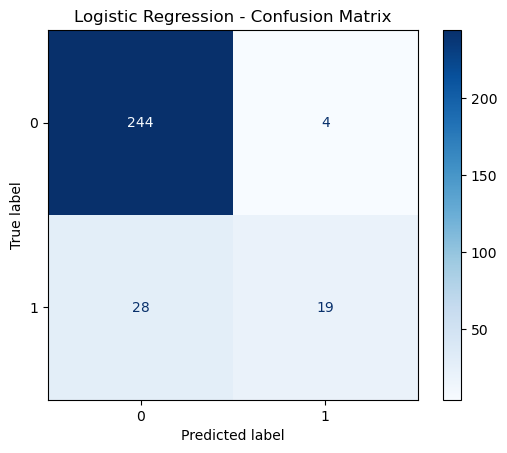

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [52]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc)

ROC AUC Score: 0.8532944406314344


In [54]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [56]:
y_pred_dt = dt.predict(X_test)

In [58]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%")

Accuracy: 80.34%


In [60]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88       248
           1       0.40      0.47      0.43        47

    accuracy                           0.80       295
   macro avg       0.65      0.67      0.66       295
weighted avg       0.82      0.80      0.81       295



In [62]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)


[[215  33]
 [ 25  22]]


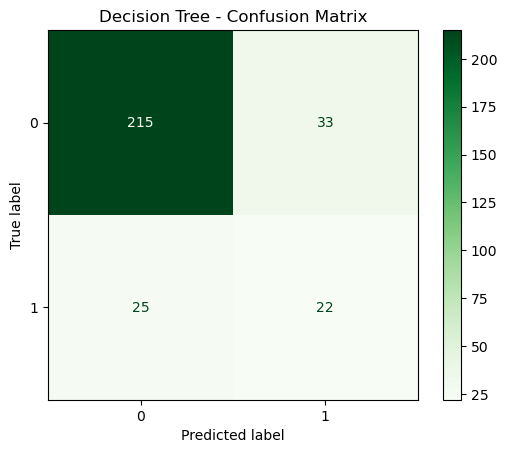

In [64]:
ConfusionMatrixDisplay(confusion_matrix=cm_dt).plot(cmap="Greens")

plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [66]:
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("ROC AUC Score:", roc_auc_score(y_test, y_prob_dt))

ROC AUC Score: 0.6675102951269732


In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [70]:
y_pred_rf = rf.predict(X_test)


In [72]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

Accuracy: 86.10%


In [74]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       248
           1       0.80      0.17      0.28        47

    accuracy                           0.86       295
   macro avg       0.83      0.58      0.60       295
weighted avg       0.85      0.86      0.82       295



In [76]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[246   2]
 [ 39   8]]


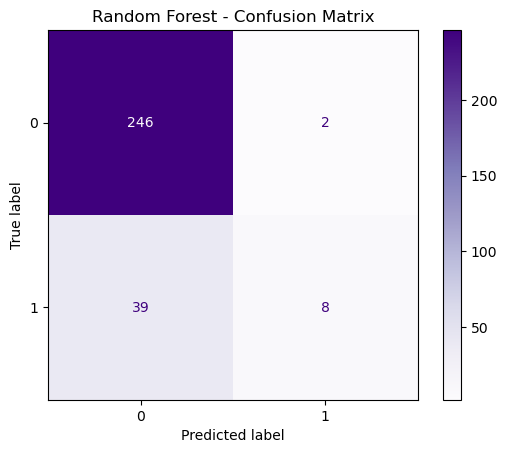

In [78]:
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap="Purples")

plt.title("Random Forest - Confusion Matrix")

plt.show()

In [80]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

ROC AUC Score: 0.8428706245710363


## Feature Importance

In [82]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
16,MonthlyIncome,0.079154
3,DailyRate,0.060112
20,OverTime,0.053472
0,Age,0.052686
5,DistanceFromHome,0.050458
18,MonthlyRate,0.050379
25,TotalWorkingYears,0.046889
10,HourlyRate,0.045551
28,YearsAtCompany,0.044291
21,PercentSalaryHike,0.035784


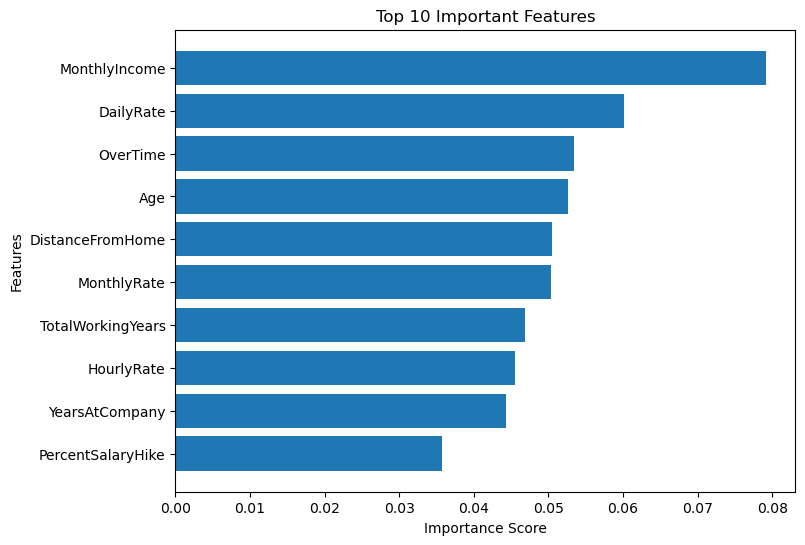

In [84]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [86]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy":[89.15,80.34,86.10],
    "Precision":[0.83,0.40,0.80],
    "Recall":[0.40,0.47,0.17],
    "F1 Score":[0.54,0.43,0.28],
    "ROC-AUC":[0.853,0.668,0.843]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,89.15,0.83,0.40,0.54,0.853
1,Decision Tree,80.34,0.40,0.47,0.43,0.668
2,Random Forest,86.10,0.80,0.17,0.28,0.843


## Best Performing Model

Among all the machine learning models, Logistic Regression achieved the best overall performance.

- Accuracy: 89.15%
- ROC-AUC Score: 0.853

Therefore, Logistic Regression was selected as the final model for predicting employee attrition.

## Business Insights

- Employees working overtime are more likely to leave the company.
- Job satisfaction and work-life balance play an important role in employee retention.
- Monthly income and years at the company also influence attrition.
- HR can use this model to identify employees at risk and take preventive actions.

## Conclusion

This project developed an employee attrition prediction model using Machine Learning.

Three classification models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.

After comparing their performance, Logistic Regression was selected as the best-performing model with an accuracy of 89.15%.
